In [95]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.nn as nn
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

from os.path import join as path_join
from neuralop import LpLoss
from scipy.ndimage import zoom
import os
from neuralop.losses import H1Loss
from scipy.interpolate import RegularGridInterpolator
import gc

FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf", "t002.hdf"]
# FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf"]
DEFAULT_RESOLUTIONS = ['medium', 'high']
BASE_DIR =  '/data/solar_wind_pred_vignesh/ParamNetwork_Paper'
component_list = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]
PER_SAMPLE_PER_COMPONENT_METRICS = ['MSE','PSNR','UQI', 'NNSE', 'EMV', 'ACC']
import pandas as pd
import seaborn as sns

In [4]:
result_dir = os.path.join(BASE_DIR, '2026_04_01__065102/result_array')

In [87]:
step = 8
step = 12
cr = 'cr1653'
cr = 'cr2113'
result_file = f'result_step_{step:04d}_{cr}.npz'
result_step = os.path.join(result_dir, result_file)
print(result_step)

/data/solar_wind_pred_vignesh/ParamNetwork_Paper/2026_04_01__065102/result_array/result_step_0012_cr2113.npz


In [88]:
f = np.load(result_step)

In [89]:
y_true, pred, cr_num = f['y_true'], f['pred'], f['cr']
y_true.shape, pred.shape

((9, 109, 128), (9, 109, 128))

In [85]:
import os
import re
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# LABEL_CONFIG = {
#     "vt": {"cmap": "gnuplot", "title": r"$v_\theta$"},
#     "vp": {"cmap": "gnuplot", "title": r"$v_\phi$"},
#     "bt": {"cmap": "coolwarm", "title": r"$\mathbf{B}_\theta$"},
#     "bp": {"cmap": "coolwarm", "title": r"$\mathbf{B}_\phi$"},
#     "jt": {"cmap": "inferno", "title": r"$\mathbf{J}_\theta$"},
#     "jp": {"cmap": "inferno", "title": r"$\mathbf{J}_\phi$"},
#     "jr": {"cmap": "inferno", "title": r"$\mathbf{J}_r$"},
#     "rho": {"cmap": "viridis", "title": r"$\rho$"},
#     "p": {"cmap": "viridis", "title": r"$p$"}
# }

LABEL_CONFIG = {
    "vt": {"cmap": "viridis", "title": r"$v_\theta (cm/s)$"},
    "vp": {"cmap": "viridis", "title": r"$v_\phi (cm/s)$"},
    "bt": {"cmap": "viridis", "title": r"$\mathbf{B}_\theta (G)$"},
    "bp": {"cmap": "viridis", "title": r"$\mathbf{B}_\phi (G)$"},
    "jt": {"cmap": "viridis", "title": r"$\mathbf{J}_\theta (statA/cm^2)$"},
    "jp": {"cmap": "viridis", "title": r"$\mathbf{J}_\phi (statA/cm^2)$"},
    "jr": {"cmap": "viridis", "title": r"$\mathbf{J}_r (statA/cm^2)$"},
    "rho": {"cmap": "viridis", "title": r"$\rho  (g/cm^3)$"},
    "p": {"cmap": "viridis", "title": r"$p (dyn/cm^2)$"}
}

def create_initial_param_plot(y_true, pred, labels, folder_path="./", file_name="initial_param_comparison.png", cmap="viridis", dpi=200, save_file=False):
    assert y_true.shape == pred.shape, "y_true and pred must have the same shape (C, H, W)"
    
    output_path = os.path.join(folder_path, file_name)
    n_components = y_true.shape[0]
    fig, ax = plt.subplots(3, n_components, figsize=(n_components*5, 11))
    for i in range(n_components):
        vmin = np.min([y_true[i].min(), pred[i].min()])
        vmax = np.max([y_true[i].max(), pred[i].max()])

        im0 = ax[0, i].imshow(y_true[i], cmap=f'{LABEL_CONFIG[labels[i]]["cmap"]}', vmin=vmin, vmax=vmax)
        # ax[0, i].axis('off')
        ax[0, i].set_title(f'{LABEL_CONFIG[labels[i]]["title"]}', fontsize=28)

        im1 = ax[1, i].imshow(pred[i], cmap=f'{LABEL_CONFIG[labels[i]]["cmap"]}', vmin=vmin, vmax=vmax)
        # ax[1, i].axis('off')
        # ax[1, i].set_title(f'{labels[i]} pred')
        
        diff = y_true[i] - pred[i]
        im2 = ax[2, i].imshow(diff, cmap='coolwarm', vmin=diff.min(), vmax=diff.max())
        # ax[2, i].axis('off')
        # ax[2, i].set_title(f'{labels[i]} diff [T - P]')
        for row in range(3):
            ax[row, i].set_xticks([])
            ax[row, i].set_yticks([])

        if i == 0:
            ax[0, 0].set_ylabel("GT", fontsize=38)
            ax[1, 0].set_ylabel("P", fontsize=38)
            ax[2, 0].set_ylabel("Diff", fontsize=38)
        # colorbar for each image, same scale (vmin/vmax) within the row
        cbar0 = fig.colorbar(im0, ax=ax[0, i], fraction=0.04, pad=0.04)
        cbar1 = fig.colorbar(im1, ax=ax[1, i], fraction=0.04, pad=0.04)
        cbar2 = fig.colorbar(im2, ax=ax[2, i], fraction=0.04, pad=0.04)
        # cbar0.ax.tick_params(labelsize=24)
        # cbar1.ax.tick_params(labelsize=24)
        # cbar2.ax.tick_params(labelsize=24)
    
    plt.tight_layout()
    if save_file:
        plt.savefig(f'{output_path}.png', dpi=dpi)
        plt.savefig(f'{output_path}.pdf', dpi=dpi)
        print(f"Initial parameter comparison plot saved to {output_path}.png")
    else:
        plt.show()
    plt.close(fig)


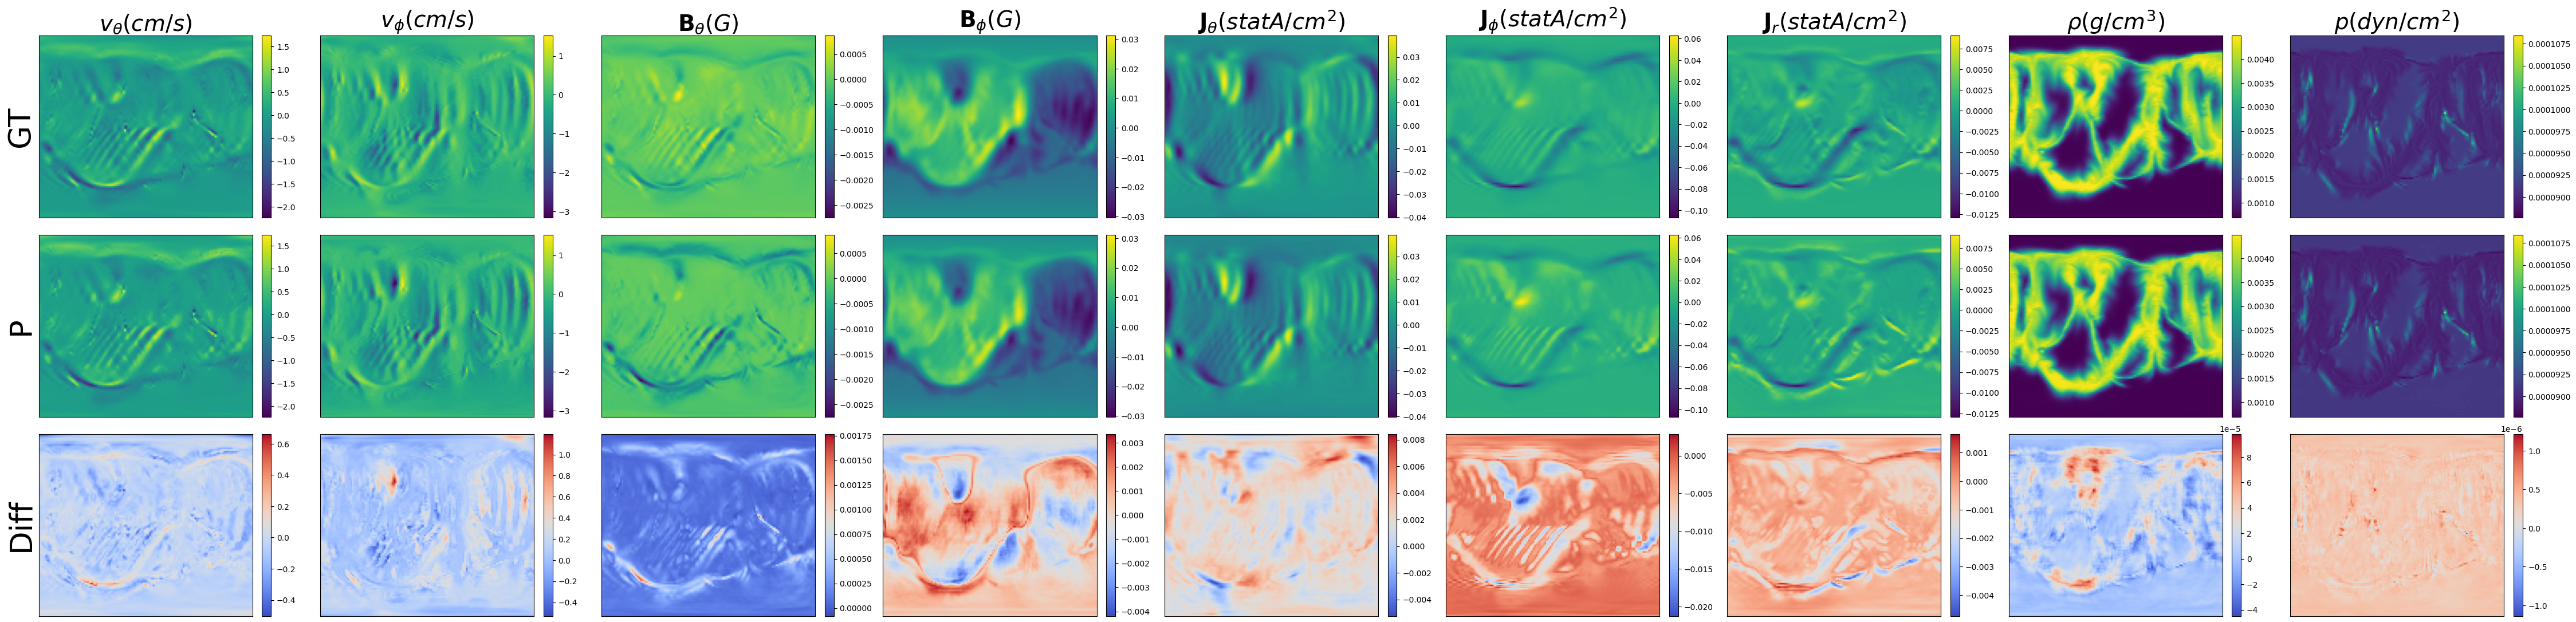

In [90]:
LABELS = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]
create_initial_param_plot(y_true,pred,LABELS)

In [91]:
y_t_u = y_true / 481.3711
y_p_u = pred / 481.3711

In [92]:
mas_to_cgs = np.array([
    4.813711e7,     # VR_0   cm/s
    2.2068908,      # BR_0   G
    4.813711e7,     # VT_0   cm/s
    4.813711e7,     # VP_0   cm/s
    2.2068908,      # BT_0   G
    2.2068908,      # BP_0   G
    0.07558,        # JT_0   statA/cm^2
    0.07558,        # JP_0   statA/cm^2
    0.07558,        # JR_0   statA/cm^2
    1.6726e-16,     # RHO_0  g/cm^3
    0.3875717,      # P_0    dyn/cm^2
], dtype=np.float32)

In [93]:
y_t_cgs = y_t_u * mas_to_cgs[2:,np.newaxis, np.newaxis]
y_p_cgs = y_p_u * mas_to_cgs[2:,np.newaxis, np.newaxis]

In [94]:
create_initial_param_plot(y_t_cgs,y_p_cgs,LABELS, folder_path='./initial_param_plots', file_name=f'result_step_{step:04d}_{cr}', save_file=True)

Initial parameter comparison plot saved to ./initial_param_plots/result_step_0012_cr2113.png


In [114]:
file_path = "/data/solar_wind_pred_vignesh/hdf/medium/cr2151/hmi_mast_mas_std_0101"
file_paths = [file_path]*5

In [111]:
import sys
sys.path.append("..")
from initial_param_dataloader import get_sim, get_sims

In [112]:
sims = get_sim(file_path, scale_up=1)

In [115]:
sims, temps = get_sims(file_paths, scale_up=1)

Loading simulations: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.44it/s]

Loaded 5 simulations with shape (11, 109, 128) and temperatures with shape (109, 128)
sims: (5, 11, 109, 128)
temps: (5, 109, 128)


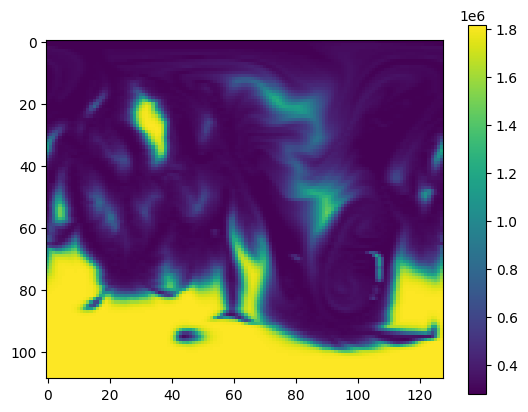

In [122]:
MAS_TEMP_TO_K = 2.807067e7  # K

temp_kelvin = temps * MAS_TEMP_TO_K
plt.imshow(temp_kelvin[0])
plt.colorbar()
plt.show()

In [110]:
temps.shape

AttributeError: 'tuple' object has no attribute 'shape'